# link 1
https://www.analyticsvidhya.com/blog/2021/04/insight-into-svm-support-vector-machine-along-with-code/

# link 2
https://www.adeveloperdiary.com/data-science/machine-learning/support-vector-machines-for-beginners-linear-svm/

In [58]:
# Import libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [59]:
# load dataset
df = pd.read_csv('drug200.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


# Try to predict the type of drug on basis of features

In [60]:
# Get the basic info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


**About the dataset:**

Age: Age of patient

Sex: Gender of patient

BP: Blood pressure of patient

Cholesterol: Cholesterol of patient

Na_to_K: Sodium to Potassium Ratio in Blood

Drug: Drug Type

In [61]:
# stastical info
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200.0,44.315000,16.544315,15.000,31.0000,45.0000,58.00,74.000
Na_to_K,200.0,16.084485,7.223956,6.269,10.4455,13.9365,19.38,38.247


In [62]:
# To print the number of rows and columsn of data
print('Rows =', df.shape[0])
print('Columns =', df.shape[1])

Rows = 200
Columns = 6


In [63]:
# check the null values in dataset 
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [64]:
# check the duplicate values
df.duplicated().sum()

np.int64(0)

In [65]:
list(df['Sex'].unique())

['F', 'M']

In [66]:
# We try to find all the unique values in object colums
obj_dict = {}
for i in df.columns:
    if df[i].dtype == 'O':
        obj_dict[i] = list(df[i].unique())
obj_dict

{'Sex': ['F', 'M'],
 'BP': ['HIGH', 'LOW', 'NORMAL'],
 'Cholesterol': ['HIGH', 'NORMAL'],
 'Drug': ['DrugY', 'drugC', 'drugX', 'drugA', 'drugB']}

In [10]:
# count the frequency of drug type
df['Drug'].value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

In [11]:
# Now do some feature engineering to covnert the categorical data into numeric
# Method 1 .map
d_gen = {'M':1, "F":0}
df['Gender'] = df['Sex'].map(d_gen)
# after conversion drop the Sex
df = df.drop('Sex', axis = 1)

In [12]:
df.sample(10)

,Age,BP,Cholesterol,Na_to_K,Drug,Gender
50,58,HIGH,HIGH,19.416,DrugY,0
181,59,NORMAL,HIGH,13.884,drugX,0
178,39,NORMAL,HIGH,15.969,DrugY,1
193,72,LOW,HIGH,6.769,drugC,1
146,37,LOW,NORMAL,12.006,drugX,0
54,68,HIGH,NORMAL,10.189,drugB,0
174,42,HIGH,NORMAL,12.766,drugA,1
134,42,HIGH,HIGH,21.036,DrugY,0
7,41,LOW,HIGH,11.037,drugC,1
31,74,HIGH,HIGH,9.567,drugB,1


In [13]:
# Now Label encode the drug column 
d_drug = {'DrugY':1, 'drugC':2, 'drugX':3, 'drugA':4, 'drugB': 5}
df['Drug_Num'] = df['Drug'].map(d_drug)
# after conversion drop the Sex
df = df.drop('Drug', axis = 1)

In [14]:
df.sample(10)

,Age,BP,Cholesterol,Na_to_K,Gender,Drug_Num
4,61,LOW,HIGH,18.043,0,1
22,47,LOW,NORMAL,30.568,1,1
181,59,NORMAL,HIGH,13.884,0,3
98,20,HIGH,NORMAL,35.639,1,1
47,68,LOW,HIGH,10.291,1,2
134,42,HIGH,HIGH,21.036,0,1
33,65,HIGH,NORMAL,31.876,0,1
16,69,LOW,NORMAL,11.455,1,3
23,48,LOW,HIGH,15.036,0,1
41,58,HIGH,NORMAL,14.239,0,5


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   BP           200 non-null    object 
 2   Cholesterol  200 non-null    object 
 3   Na_to_K      200 non-null    float64
 4   Gender       200 non-null    int64  
 5   Drug_Num     200 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 9.5+ KB


In [16]:
# Now one hot encode the some object feature
df1 = pd.get_dummies(columns=['BP', 'Cholesterol'], data = df, drop_first = True, dtype = int)
df1

,Age,Na_to_K,Gender,Drug_Num,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,25.355,0,1,0,0,0
1,47,13.093,1,2,1,0,0
2,47,10.114,1,2,1,0,0
3,28,7.798,0,3,0,1,0
4,61,18.043,0,1,1,0,0
...,...,...,...,...,...,...,...
195,56,11.567,0,2,1,0,0
196,16,12.006,1,2,1,0,0
197,52,9.894,1,3,0,1,0
198,23,14.020,1,3,0,1,1


In [17]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 200 non-null    int64  
 1   Na_to_K             200 non-null    float64
 2   Gender              200 non-null    int64  
 3   Drug_Num            200 non-null    int64  
 4   BP_LOW              200 non-null    int64  
 5   BP_NORMAL           200 non-null    int64  
 6   Cholesterol_NORMAL  200 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 11.1 KB


In [18]:
# Basic EDA

<Axes: ylabel='Age'>

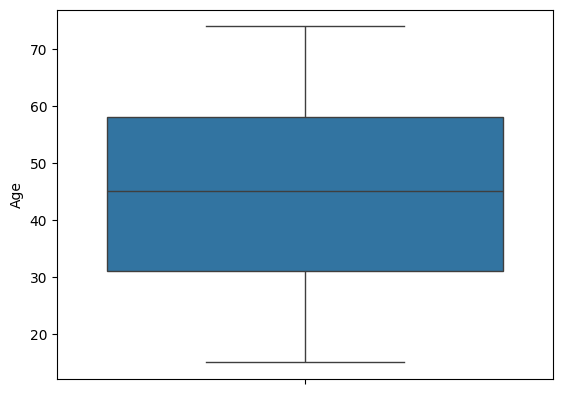

In [19]:
sns.boxplot(df1['Age'])

<Axes: ylabel='Na_to_K'>

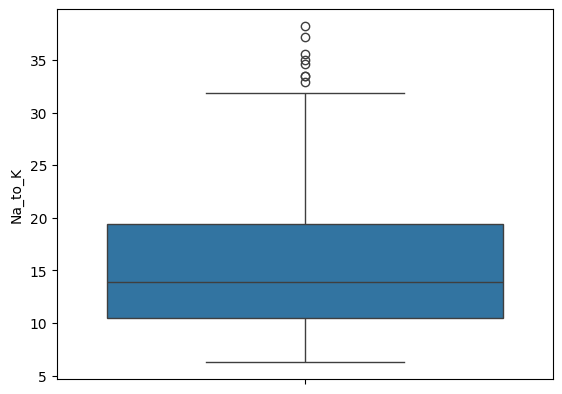

In [20]:
sns.boxplot(df1['Na_to_K'])

<Axes: xlabel='Cholesterol_NORMAL', ylabel='Age'>

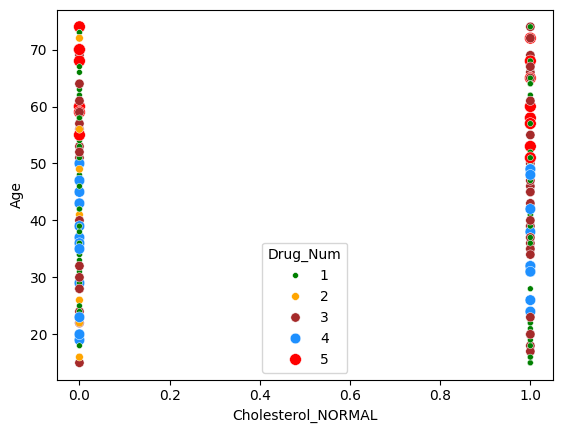

In [21]:
sns.scatterplot(y= df1['Age'],x = df1['Cholesterol_NORMAL'], hue = df1['Drug_Num'], size =  df1['Drug_Num'],
                palette=['green','orange','brown','dodgerblue','red'], legend='full')

<Axes: xlabel='Na_to_K', ylabel='Age'>

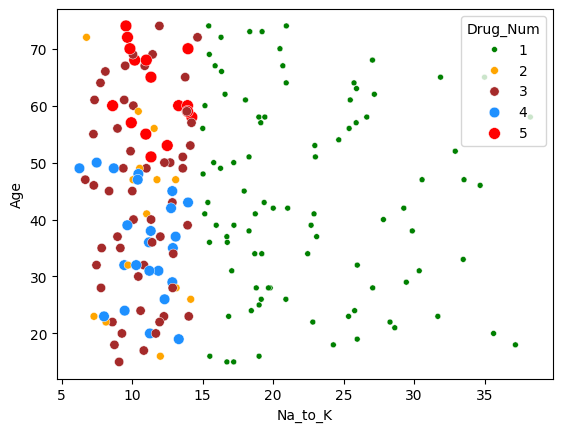

In [22]:
sns.scatterplot(y= df1['Age'],x = df1['Na_to_K'], hue = df1['Drug_Num'], size =  df1['Drug_Num'],
                palette=['green','orange','brown','dodgerblue','red'], legend='full')

<Axes: xlabel='BP_LOW', ylabel='Age'>

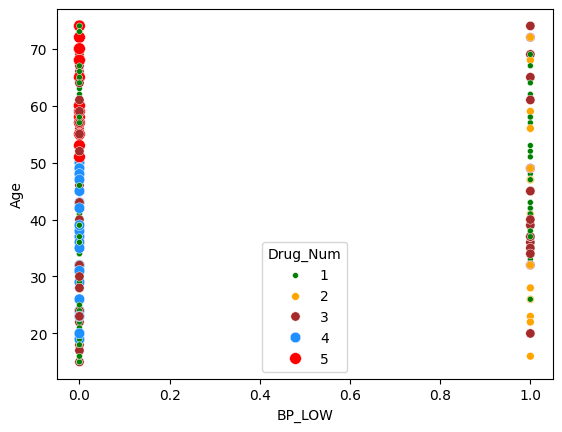

In [23]:
sns.scatterplot(y= df1['Age'],x = df1['BP_LOW'], hue = df1['Drug_Num'], size =  df1['Drug_Num'],
                palette=['green','orange','brown','dodgerblue','red'], legend='full')

In [24]:
def bps(x):
    if x == 'LOW':
        return 0
    elif x == 'NORMAL':
        return 1
    else:
        return 2
df1['BP_st'] = df['BP'].apply(bps)
df1['BP_st']

0      2
1      0
2      0
3      1
4      0
      ..
195    0
196    0
197    1
198    1
199    0
Name: BP_st, Length: 200, dtype: int64

<Axes: xlabel='BP_st', ylabel='Age'>

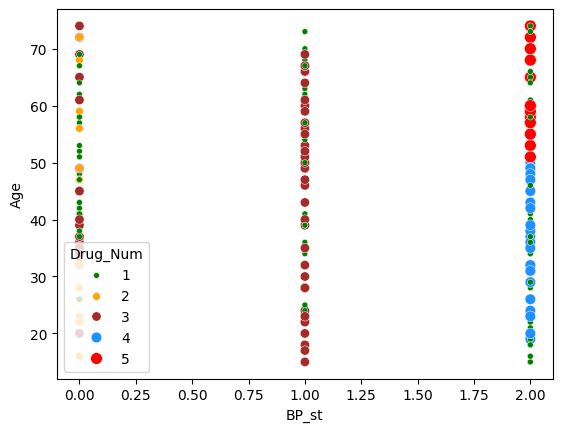

In [25]:
sns.scatterplot(y= df1['Age'],x = df1['BP_st'], hue = df1['Drug_Num'], size =  df1['Drug_Num'],
                palette=['green','orange','brown','dodgerblue','red'], legend='full')

<Axes: xlabel='BP_st', ylabel='Gender'>

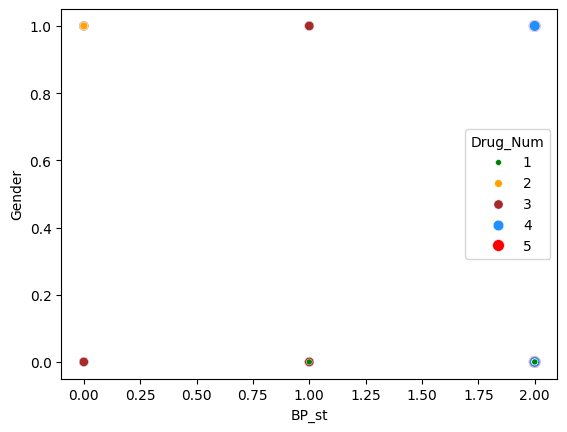

In [26]:
sns.scatterplot(y= df1['Gender'],x = df1['BP_st'], hue = df1['Drug_Num'], size =  df1['Drug_Num'],
                palette=['green','orange','brown','dodgerblue','red'], legend='full')

<Axes: xlabel='BP_st', ylabel='Cholesterol_NORMAL'>

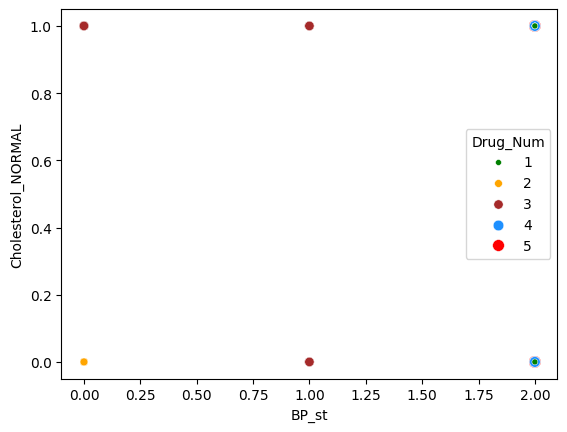

In [27]:
sns.scatterplot(y= df1['Cholesterol_NORMAL'],x = df1['BP_st'], hue = df1['Drug_Num'], size =  df1['Drug_Num'],
                palette=['green','orange','brown','dodgerblue','red'], legend='full')

<Axes: >

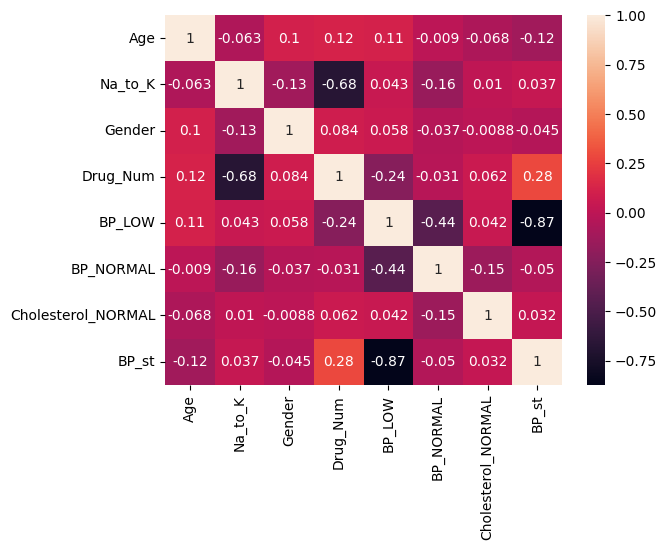

In [28]:
sns.heatmap(df1.corr(),annot = True)

In [29]:
# Divide the data into independent(x) and dependent data (y)
x = df1.drop(['Drug_Num','BP_st'],axis = 1)
x.head()

,Age,Na_to_K,Gender,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,25.355,0,0,0,0
1,47,13.093,1,1,0,0
2,47,10.114,1,1,0,0
3,28,7.798,0,0,1,0
4,61,18.043,0,1,0,0


In [30]:
y = df1['Drug_Num']
y.head()

0    1
1    2
2    2
3    3
4    1
Name: Drug_Num, dtype: int64

In [31]:
# We Will use minmaxScaler to normalize data if there are very less outliers otherwise we use 
# StandardScaler to normalize data

# import standard scaler
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# from sklearn.preprocessing import MinMaxScaler
# sc = MinMaxScaler()


In [32]:
x_sc = sc.fit_transform(x)
x_sc

array([[-1.29159102,  1.28652212, -1.040833  , -0.68599434, -0.64686916,
        -0.97043679],
       [ 0.16269866, -0.4151454 ,  0.96076892,  1.45773797, -0.64686916,
        -0.97043679],
       [ 0.16269866, -0.82855818,  0.96076892,  1.45773797, -0.64686916,
        -0.97043679],
       ...,
       [ 0.46567567, -0.85908883,  0.96076892, -0.68599434,  1.54590766,
        -0.97043679],
       [-1.29159102, -0.28650033,  0.96076892, -0.68599434,  1.54590766,
         1.03046381],
       [-0.26146916, -0.6571702 , -1.040833  ,  1.45773797, -0.64686916,
         1.03046381]], shape=(200, 6))

In [33]:
sc.inverse_transform([x_sc[0]])

array([[23.   , 25.355,  0.   ,  0.   ,  0.   ,  0.   ]])

In [34]:
# Now we have done the data preprocessing  now split data into train and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_sc, y, test_size=0.3, random_state=180,
                                                    stratify=y)

In [35]:
# # Now we have done the data preprocessing  now split data into train and test
# from sklearn.model_selection import train_test_split
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=180,
#                                                     stratify=y)

In [36]:
# check the shape of splited data
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(140, 6) (60, 6)
(140,) (60,)


In [37]:
# Now import the model and train the model 
from sklearn.svm import SVC
sv = SVC()

In [38]:
# train the model
sv.fit(x_train, y_train)

SVC()

In [39]:
# Training Score of model
sv.score(x_train, y_train)

0.9714285714285714

In [40]:
y_pred = sv.predict(x_test)
y_pred

array([3, 1, 2, 3, 4, 1, 2, 3, 5, 1, 5, 1, 3, 1, 1, 3, 1, 3, 1, 1, 1, 3,
       3, 4, 1, 1, 4, 4, 5, 3, 3, 5, 1, 4, 1, 2, 1, 3, 1, 2, 4, 3, 1, 2,
       3, 1, 5, 3, 3, 1, 1, 1, 1, 1, 1, 4, 5, 3, 5, 1])

In [41]:
# Now do the evaluation of model
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
def model_evaluation(y_actual, y_prediction):
    print('Accuracy_Score = ',accuracy_score(y_actual, y_prediction))
    print('Confusion Matrix \n',confusion_matrix(y_actual, y_prediction))
    sns.heatmap(confusion_matrix(y_actual, y_prediction), annot = True, fmt = '.2f')
    print('Classification_Report \n',classification_report(y_actual, y_prediction))

Accuracy_Score =  0.9666666666666667
Confusion Matrix 
 [[25  0  0  0  2]
 [ 0  5  0  0  0]
 [ 0  0 16  0  0]
 [ 0  0  0  7  0]
 [ 0  0  0  0  5]]
Classification_Report 
               precision    recall  f1-score   support

           1       1.00      0.93      0.96        27
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00         7
           5       0.71      1.00      0.83         5

    accuracy                           0.97        60
   macro avg       0.94      0.99      0.96        60
weighted avg       0.98      0.97      0.97        60



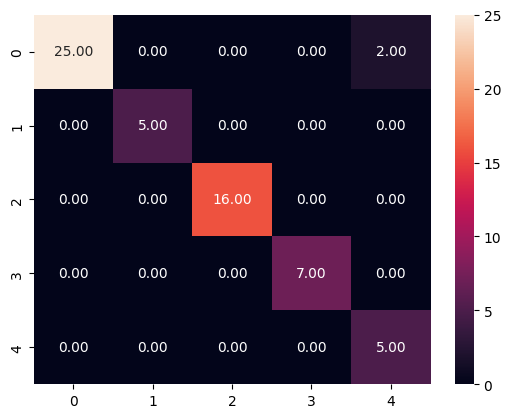

In [42]:
model_evaluation(y_test, y_pred)

In [43]:
sv.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

# Import model and hyperparameter tuning(GridsearchCV)

In [44]:
# Import Grid SearchCV
from sklearn.model_selection import GridSearchCV

In [45]:
grd_model = SVC()

In [46]:
param_grid = {'C':np.arange(1,10,0.5),
    'kernel':['rbf','poly','linear'],
    'gamma':['scale', 0.6]}

In [47]:
grd_model = GridSearchCV(grd_model, param_grid, refit = True, verbose = 3)

In [48]:
grd_model.fit(x_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5] END ....C=1.0, gamma=scale, kernel=rbf;, score=0.821 total time=   0.0s
[CV 2/5] END ....C=1.0, gamma=scale, kernel=rbf;, score=0.893 total time=   0.0s
[CV 3/5] END ....C=1.0, gamma=scale, kernel=rbf;, score=0.893 total time=   0.0s
[CV 4/5] END ....C=1.0, gamma=scale, kernel=rbf;, score=0.714 total time=   0.0s
[CV 5/5] END ....C=1.0, gamma=scale, kernel=rbf;, score=0.929 total time=   0.0s
[CV 1/5] END ...C=1.0, gamma=scale, kernel=poly;, score=0.857 total time=   0.0s
[CV 2/5] END ...C=1.0, gamma=scale, kernel=poly;, score=0.821 total time=   0.0s
[CV 3/5] END ...C=1.0, gamma=scale, kernel=poly;, score=0.857 total time=   0.0s
[CV 4/5] END ...C=1.0, gamma=scale, kernel=poly;, score=0.786 total time=   0.0s
[CV 5/5] END ...C=1.0, gamma=scale, kernel=poly;, score=0.929 total time=   0.0s
[CV 1/5] END .C=1.0, gamma=scale, kernel=linear;, score=1.000 total time=   0.0s
[CV 2/5] END .C=1.0, gamma=scale, kernel=linea

GridSearchCV(estimator=SVC(),
             param_grid={'C': array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. ,
       7.5, 8. , 8.5, 9. , 9.5]),
                         'gamma': ['scale', 0.6],
                         'kernel': ['rbf', 'poly', 'linear']},
             verbose=3)

In [49]:
grd_model.best_params_

{'C': np.float64(7.0), 'gamma': 'scale', 'kernel': 'linear'}

In [50]:
grd_model.best_score_

np.float64(0.9642857142857142)

In [51]:
grid_model = SVC(C=7, gamma='scale', kernel='linear')

In [52]:
grid_model.fit(x_train,y_train)

SVC(C=7, kernel='linear')

In [53]:
grid_model.score(x_train,y_train)

0.9928571428571429

In [54]:
grid_model_y_pred = grid_model.predict(x_test)

Accuracy_Score =  0.9833333333333333
Confusion Matrix 
 [[26  0  1  0  0]
 [ 0  5  0  0  0]
 [ 0  0 16  0  0]
 [ 0  0  0  7  0]
 [ 0  0  0  0  5]]
Classification_Report 
               precision    recall  f1-score   support

           1       1.00      0.96      0.98        27
           2       1.00      1.00      1.00         5
           3       0.94      1.00      0.97        16
           4       1.00      1.00      1.00         7
           5       1.00      1.00      1.00         5

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



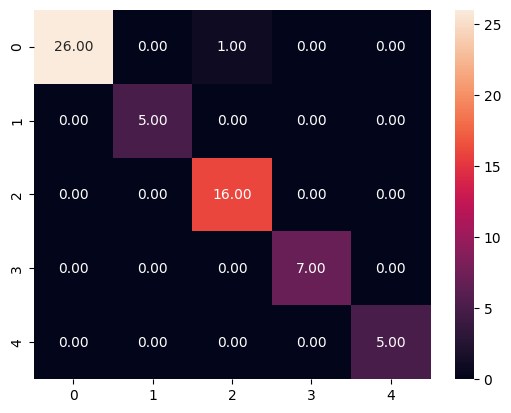

In [55]:
model_evaluation(y_test,grid_model_y_pred)

In [56]:
grid_model_y_pred = grid_model.predict(x_sc)

Accuracy_Score =  0.99
Confusion Matrix 
 [[89  0  2  0  0]
 [ 0 16  0  0  0]
 [ 0  0 54  0  0]
 [ 0  0  0 23  0]
 [ 0  0  0  0 16]]
Classification_Report 
               precision    recall  f1-score   support

           1       1.00      0.98      0.99        91
           2       1.00      1.00      1.00        16
           3       0.96      1.00      0.98        54
           4       1.00      1.00      1.00        23
           5       1.00      1.00      1.00        16

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       0.99      0.99      0.99       200



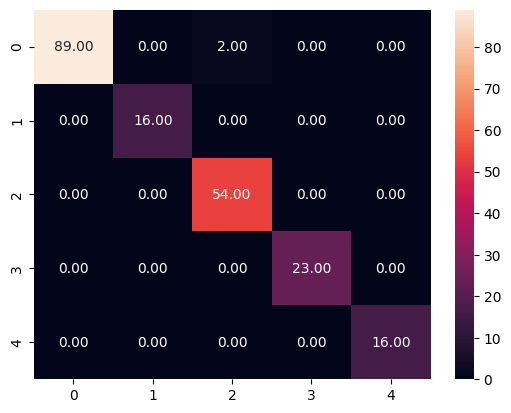

In [57]:
model_evaluation(y,grid_model_y_pred)